In [1]:
from keras.models import model_from_json
import keras
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

2024-08-02 15:14:02.565144: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-08-02 15:14:02.618937: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def load_model(variable_name = 'C', model_number = None, folder = None):
    if variable_name == 'C':
        name = 'model_7_dotson_thwaites_r1_geo_C'
    elif variable_name == 'theta':
        name = 'model_7_dotson_thwaites_r1_theta'
    if model_number is not None:
        name = name + '_' + str(model_number)
    if folder is not None:
        name = os.path.join(folder, name)

    # To load everything back from the file
    with open(name+'.pkl', "rb") as f:
        loaded_model_bundle = pickle.load(f)

    # Extract components
    loaded_model_architecture = loaded_model_bundle['model_architecture']
    loaded_model_weights = loaded_model_bundle['model_weights']
    loaded_input_scaler = loaded_model_bundle['input_scaler']
    loaded_output_scaler = loaded_model_bundle['output_scaler']
    loaded_input_columns = loaded_model_bundle['input_columns']
    loaded_output_columns = loaded_model_bundle['output_columns']

    # Reconstruct the model
    #loaded_model = model_from_json(loaded_model_architecture)
    #loaded_model.set_weights(loaded_model_weights)

    loaded_model = keras.models.load_model(name+'.h5')
    return loaded_model, loaded_input_scaler, loaded_output_scaler, loaded_input_columns, loaded_output_columns

In [3]:
def get_predictions(data, loaded_input_columns, loaded_input_scaler, loaded_output_scaler, loaded_model, variable_name = 'C'):
    
    df = data[loaded_input_columns].copy()
    df_scaled = loaded_input_scaler.transform(df.to_numpy())
    prediction = loaded_output_scaler.inverse_transform(loaded_model.predict(df_scaled).reshape(-1,1)).reshape(-1,)
    return prediction

In [4]:
column_stats = pd.read_csv('dataframe_description.csv', index_col=0)
column_stats

,s,b,h,mag_h,mag_s,mag_b,driving_stress,mag_anomaly,boug_anomaly,heatflux,C,theta
count,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049931e+06,1.049932e+06,1.049932e+06
mean,1.279465e+03,-9.285516e+02,2.188003e+03,5.963252e-02,9.000464e-03,6.195775e-02,1.309273e+02,4.242904e-01,-4.152417e+01,6.880441e+01,1.013049e+00,-5.990973e-01
std,5.169136e+02,5.609012e+02,8.477684e+02,7.130913e-02,2.083023e-02,7.484918e-02,1.325165e+02,8.444719e+01,6.115426e+02,2.808361e+00,1.782046e+00,2.540752e+00
min,-1.990880e+02,-4.837471e+03,-2.962771e+03,4.198481e-05,4.610320e-06,3.347167e-05,-1.186842e+04,-1.163270e+03,-1.650790e+04,5.780383e+01,-5.021620e+01,-1.025840e+02
25%,1.026034e+03,-1.326919e+03,1.720295e+03,2.084915e-02,2.810657e-03,2.123072e-02,6.303714e+01,-4.752337e+01,-3.845155e+00,6.754867e+01,6.388015e-01,-3.598441e-01
50%,1.395120e+03,-1.026096e+03,2.396019e+03,3.812794e-02,4.957864e-03,3.959543e-02,1.060651e+02,5.996514e+00,1.262763e+01,6.915422e+01,1.315161e+00,-7.132901e-02
75%,1.653627e+03,-5.983666e+02,2.815515e+03,7.202377e-02,8.855822e-03,7.505777e-02,1.663293e+02,4.807327e+01,2.512050e+01,7.060176e+01,1.799330e+00,-1.311363e-02
max,4.325009e+03,4.412988e+03,6.668185e+03,2.765605e+00,1.936166e+00,2.081683e+00,5.740372e+03,9.179603e+02,1.741320e+04,7.402133e+01,5.543594e+01,2.097156e+02


In [5]:
def create_input(variable_name, loaded_input_columns, stat = '50%', resolution = 100):
    
    # Initialize an empty DataFrame
    input_df = pd.DataFrame()

    # Set each column to its average value from column_stats, except the variable of interest
    for column in loaded_input_columns:
        if column != variable_name:
            mean_value = column_stats.loc[stat, column]
            input_df[column] = [mean_value] * resolution  # Create a column with 10 identical mean values
        else:
            # For the variable of interest, find its 25th and 75th percentiles
            variable_25th = column_stats.loc['25%',column]
            variable_75th = column_stats.loc['75%',column]
            
            # Generate a range of values from 25th to 75th percentile
            variable_range = np.linspace(variable_25th, variable_75th, num=resolution)  # Adjust num for desired granularity
            
            # Set the variable column in input_df to this range
            input_df[variable_name] = variable_range
    
    return input_df

In [6]:
def get_ensemble_predictions(variable_name, stat, folder = 'mlp_ensemble', number_of_models = 10, resolution = 100):
    
    loaded_model, loaded_input_scaler, loaded_output_scaler, loaded_input_columns, loaded_output_columns = load_model(variable_name=plot_variable, model_number = 0, folder = folder) #just to get loaded_input_columns
    n_vars = len(loaded_input_columns)
    input_df = create_input(variable_name, loaded_input_columns, stat, resolution=resolution)
    prediction_list = []
    for i in range(number_of_models):
        loaded_model, loaded_input_scaler, loaded_output_scaler, loaded_input_columns, loaded_output_columns = load_model(variable_name=plot_variable, model_number= i, folder = folder)
        predictions = get_predictions(input_df, loaded_input_columns, loaded_input_scaler, loaded_output_scaler, loaded_model, plot_variable)
        prediction_list.append(predictions)
    prediction_array = np.array(prediction_list)
    mean_prediction = np.mean(prediction_array, axis=0)

    percentile_50 = np.percentile(prediction_array, 50, axis=0)
    # Calculate the 25th percentile
    percentile_25 = np.percentile(prediction_array, 25, axis=0)

    # Calculate the 75th percentile
    percentile_75 = np.percentile(prediction_array, 75, axis=0)
    return percentile_50, percentile_25, percentile_75,  input_df

In [7]:
def plot_variables_with_subplots(plot_variable, stat_list, stat_list_inserts = ['25%', '50%', '75%'], resolution=100, display_names=['surface elevation (s)', 'bed elevation (b)', 'thickness (h)', '|$\\nabla h$|', '|$\\nabla s$|', '|$\\nabla b$|', 'driving_stress']):
    """
    Plots the given variables in a single figure with subplots.

    Parameters:
    plot_variable (str): The variable to be plotted.
    stat_list (list): List of statistical measures to plot.
    resolution (int): Resolution for the input data. Default is 100.
    display_names (list): Display names for the variables.
    """
    # Load the model and other necessary data
    loaded_model, loaded_input_scaler, loaded_output_scaler, loaded_input_columns, loaded_output_columns = load_model(variable_name=plot_variable)
    n_vars = len(loaded_input_columns)
    
    # Define the number of rows and columns for the subplots (3x3 grid)
    n_cols = 3
    n_rows = 3
    inset_colors = ['orange', 'green', 'red']
    # Create a figure with subplots
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 14))
    
    # Flatten the axs array for easy indexing
    axs = axs.flatten()
    
    for idx, variable_name in enumerate(loaded_input_columns):
        plt.sca(axs[idx])
        for stat in stat_list:
            input_df = create_input(variable_name, loaded_input_columns, stat, resolution=resolution)
            predictions = get_predictions(input_df, loaded_input_columns, loaded_input_scaler, loaded_output_scaler, loaded_model, plot_variable)
            axs[idx].plot(input_df[variable_name], predictions, label=stat)
        axs[idx].set_xlabel(display_names[idx])
        axs[idx].set_ylabel(plot_variable)
        axs[idx].grid()
        axs[idx].legend()
        
        # Create an inset plot
        ax_inset = inset_axes(axs[idx], width="30%", height="30%", loc="lower left")
        for stat_idx, stat in enumerate(stat_list_inserts):
            input_df = create_input(variable_name, loaded_input_columns, stat, resolution=resolution)
            predictions = get_predictions(input_df, loaded_input_columns, loaded_input_scaler, loaded_output_scaler, loaded_model, plot_variable)
            ax_inset.plot(input_df[variable_name], predictions, label=stat, color=inset_colors[stat_idx])
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.grid()
        ax_inset.grid(True)

    # Hide any remaining empty subplots
    for idx in range(len(loaded_input_columns), len(axs)):
        fig.delaxes(axs[idx])

    # Add a suptitle based on the plot_variable
    if plot_variable == 'C':
        plt.suptitle('C')
    elif plot_variable == 'theta':
        plt.suptitle('$\\theta$')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

In [15]:
def plot_variables_with_subplots_ensemble(plot_variable, stat_list, folder = 'mlp_ensemble', stat_list_inserts = ['25%', '50%', '75%'], resolution=100, display_names=['surface elevation (s)', 'bed elevation (b)', 'thickness (h)', '|$\\nabla h$|', '|$\\nabla s$|', '|$\\nabla b$|', 'driving_stress']):
    """
    Plots the given variables in a single figure with subplots.

    Parameters:
    plot_variable (str): The variable to be plotted.
    stat_list (list): List of statistical measures to plot.
    resolution (int): Resolution for the input data. Default is 100.
    display_names (list): Display names for the variables.
    """
    # Load the model and other necessary data
    loaded_model, loaded_input_scaler, loaded_output_scaler, loaded_input_columns, loaded_output_columns = load_model(variable_name=plot_variable,  model_number = 0, folder = folder)
    n_vars = len(loaded_input_columns)
    
    # Define the number of rows and columns for the subplots (3x3 grid)
    n_cols = 3
    n_rows = 3
    inset_colors = ['orange', 'green', 'red']
    colors_5 = ['blue', 'orange', 'green', 'red', 'purple']
    # Create a figure with subplots
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, 14))
    
    # Flatten the axs array for easy indexing
    axs = axs.flatten()
    
    for idx, variable_name in enumerate(loaded_input_columns):
        plt.sca(axs[idx])
        for stat in stat_list:
            predictions, percentile_25, percentile_75,  input_df = get_ensemble_predictions(variable_name, stat, folder = folder, number_of_models = 10, resolution = 100)
            axs[idx].plot(input_df[variable_name], predictions, label=stat, color = colors_5[stat_list.index(stat)])
            axs[idx].fill_between(input_df[variable_name], percentile_25, percentile_75, alpha=0.2, color = colors_5[stat_list.index(stat)])
        axs[idx].set_xlabel(display_names[idx])
        axs[idx].set_ylabel(plot_variable)
        axs[idx].grid()
        axs[idx].legend()
        
        # Create an inset plot
        ax_inset = inset_axes(axs[idx], width="30%", height="30%", loc="lower left")
        for stat_idx, stat in enumerate(stat_list_inserts):
            predictions, percentile_25, percentile_75,  input_df = get_ensemble_predictions(variable_name, stat, folder = folder, number_of_models = 10, resolution = 100)
            ax_inset.plot(input_df[variable_name], predictions, label=stat, color=inset_colors[stat_idx])
            ax_inset.fill_between(input_df[variable_name], percentile_25, percentile_75, alpha=0.2, color=inset_colors[stat_idx])
        ax_inset.set_xticks([])
        ax_inset.set_yticks([])
        ax_inset.grid()
        ax_inset.grid(True)

    # Hide any remaining empty subplots
    for idx in range(len(loaded_input_columns), len(axs)):
        fig.delaxes(axs[idx])

    # Add a suptitle based on the plot_variable
    if plot_variable == 'C':
        plt.suptitle('C')
    elif plot_variable == 'theta':
        plt.suptitle('$\\theta$')

    # Adjust layout to prevent overlap
    plt.tight_layout()

In [16]:
stat_list = ['min', '25%', '50%', '75%', 'max']

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7f04783d2160> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


/tmp/ipykernel_1229/3896351547.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


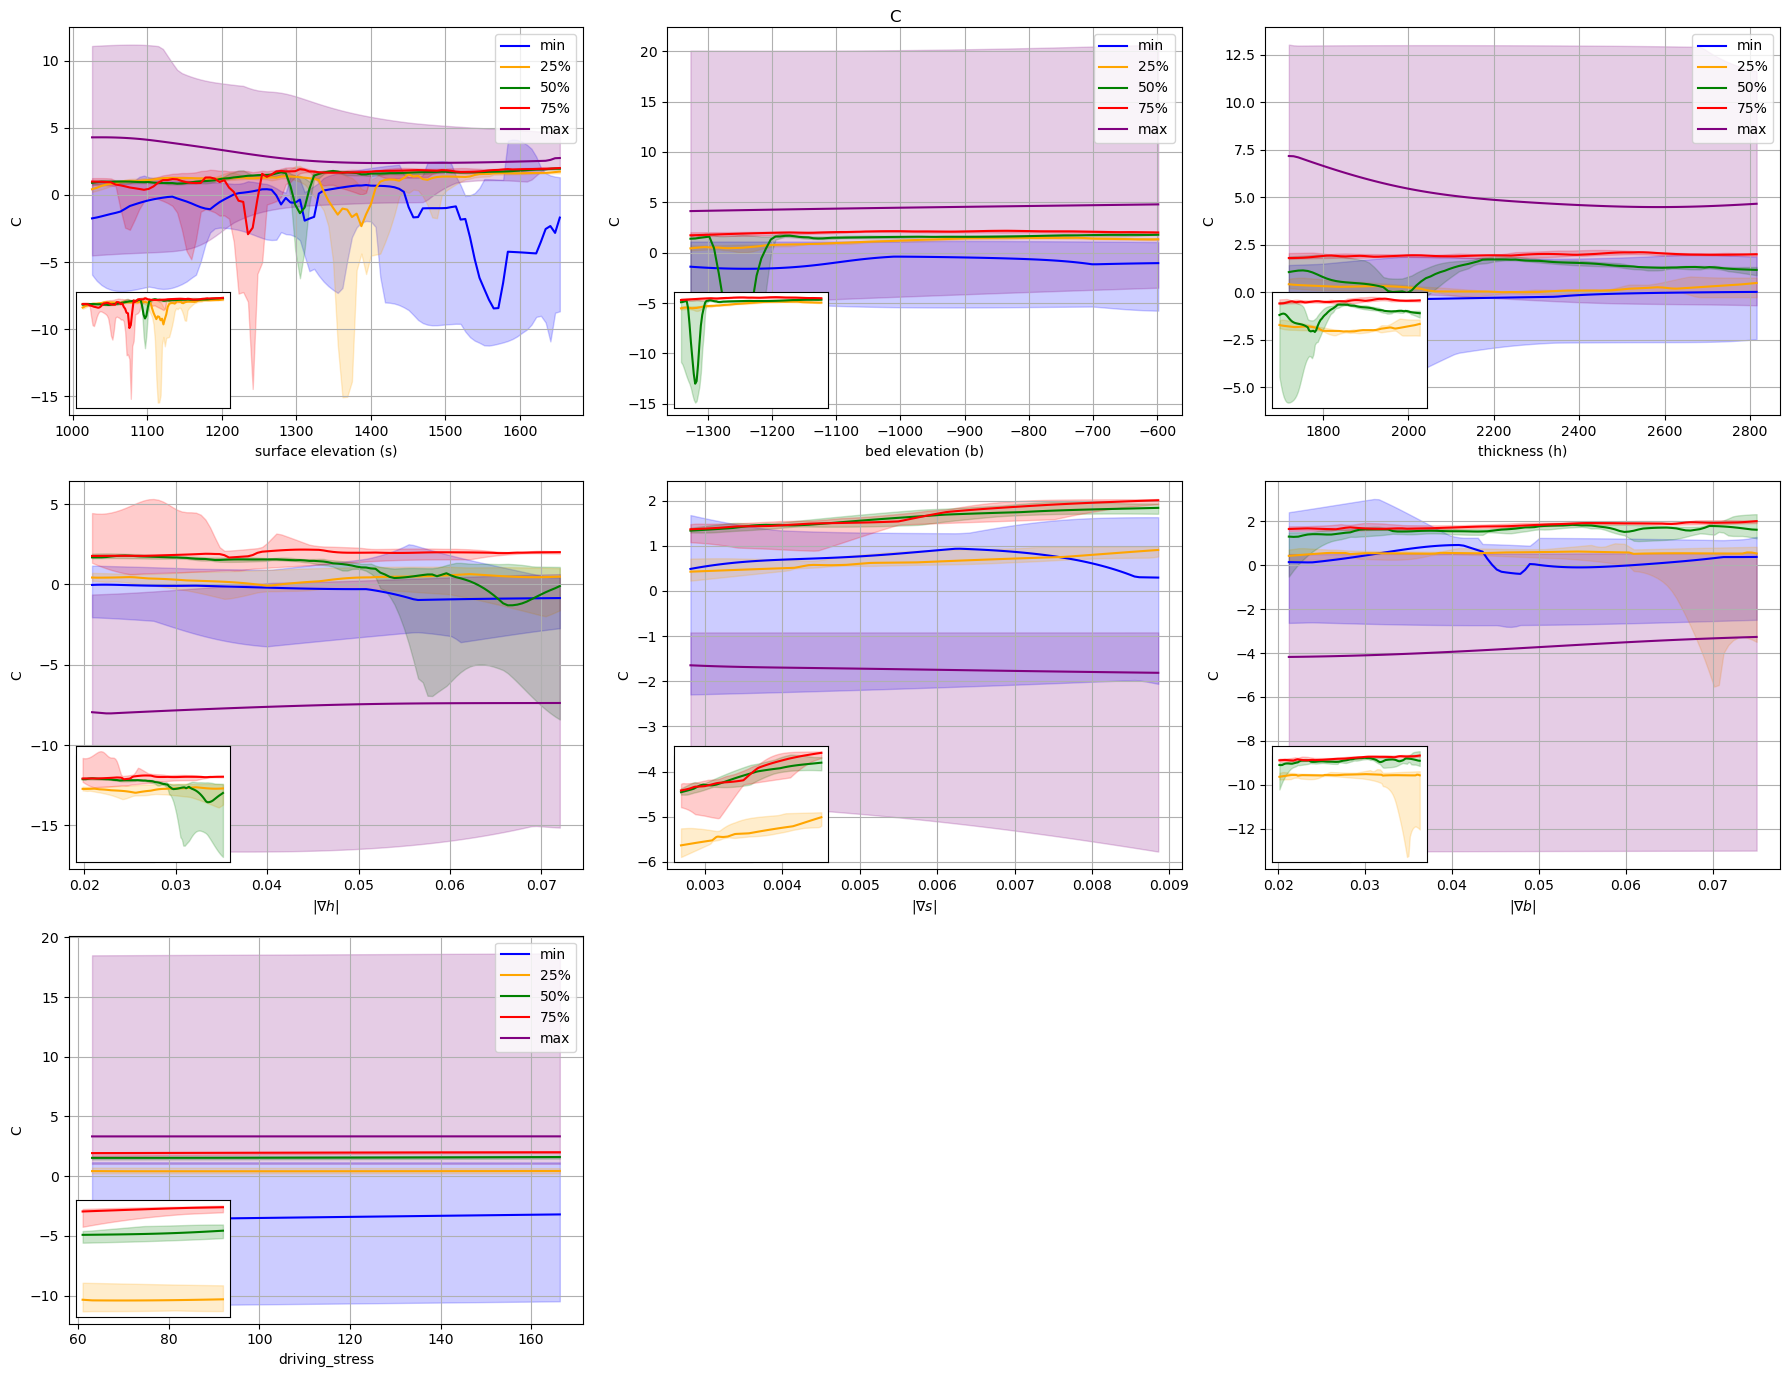

In [17]:
plot_variable = 'C'
folder = os.path.join('mlp_ensemble', '7_var')

#plot_variables_with_subplots(plot_variable, stat_list, resolution=100)
plot_variables_with_subplots_ensemble(plot_variable, stat_list, folder = folder, resolution=100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━

/tmp/ipykernel_1246/923606243.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


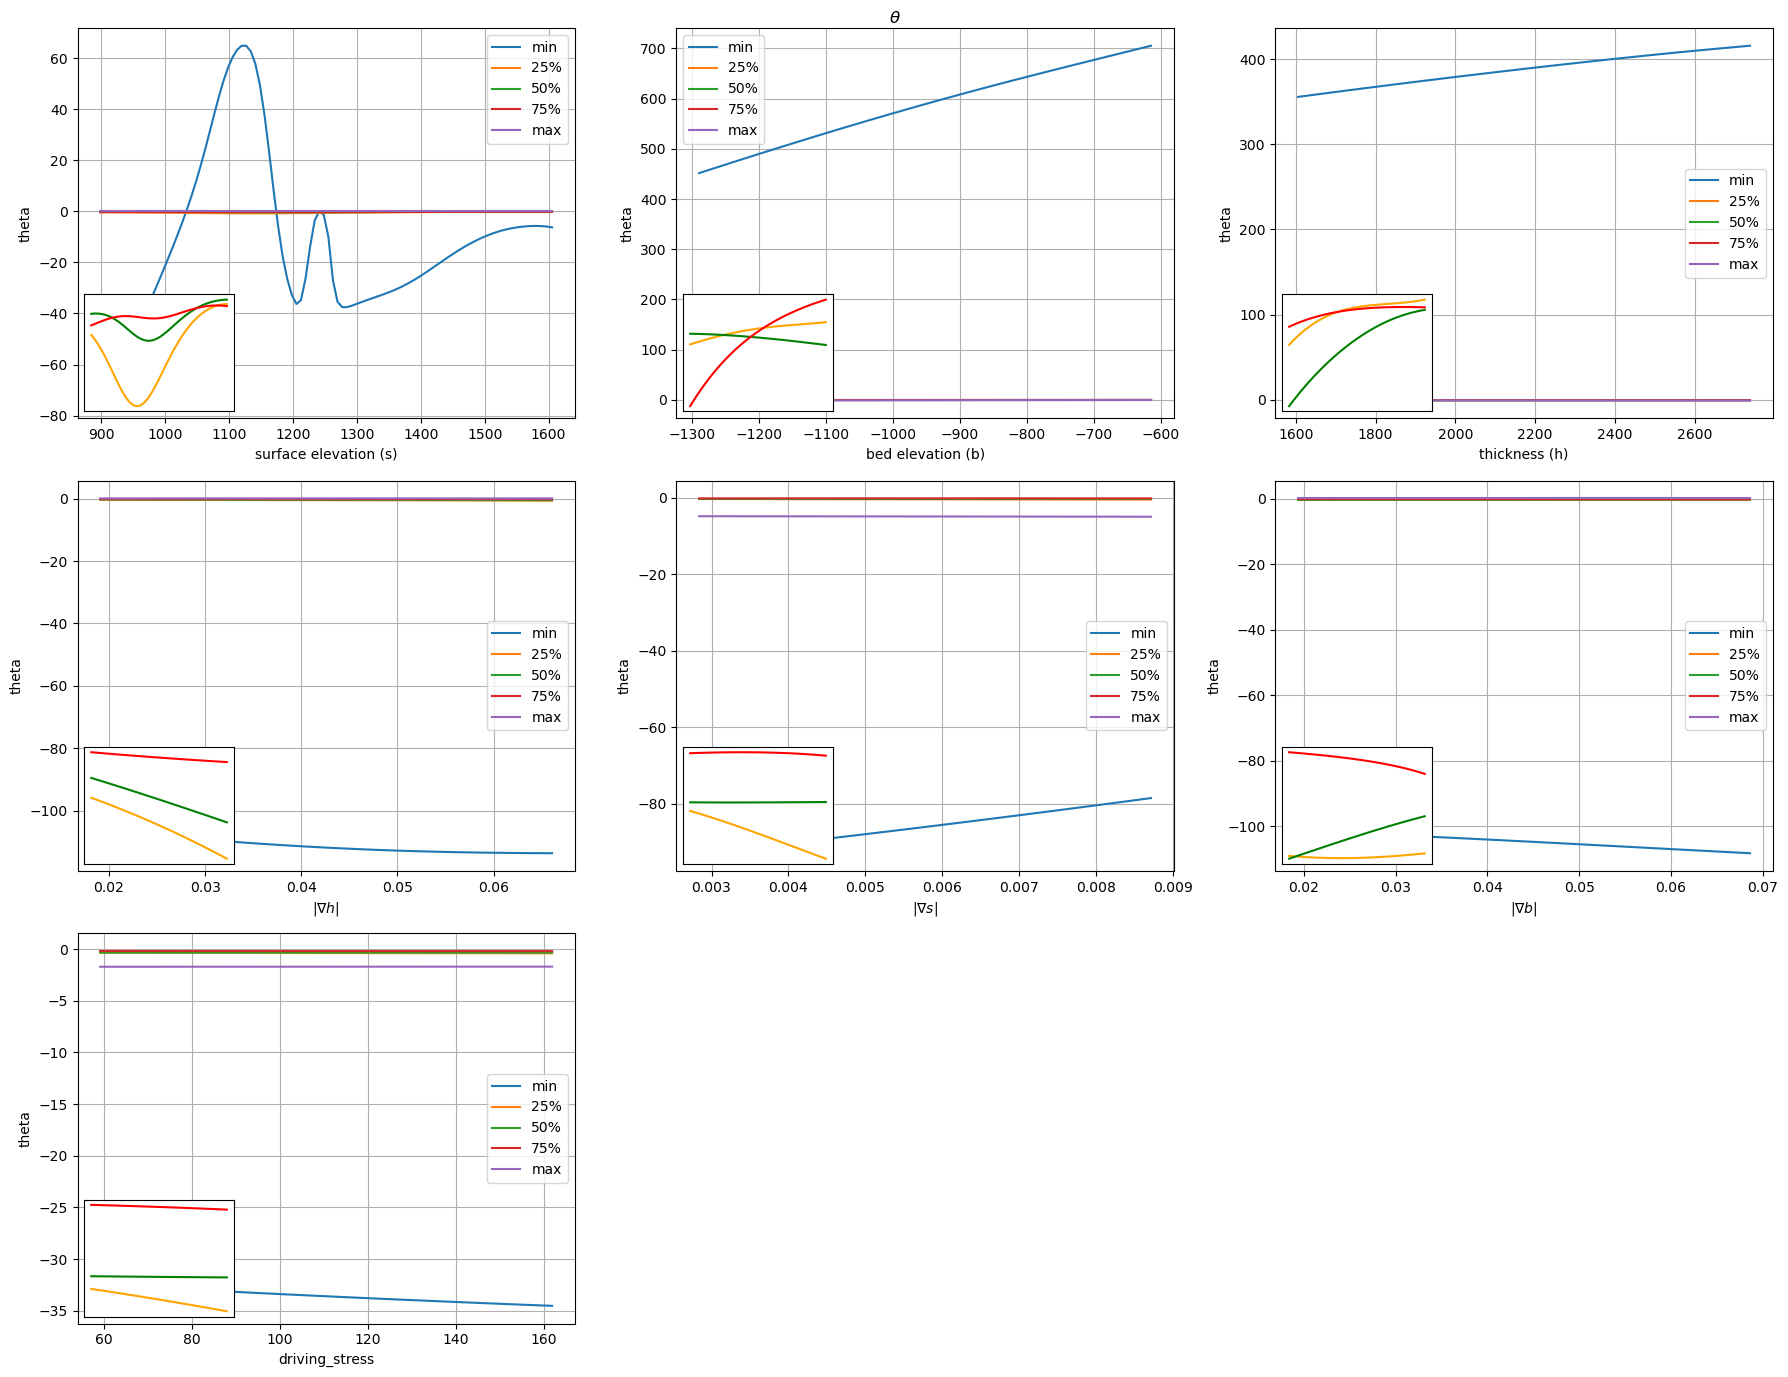

In [23]:
plot_variable = 'theta'
plot_variables_with_subplots(plot_variable, stat_list, resolution=100)